In [1]:
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.signal import savgol_filter

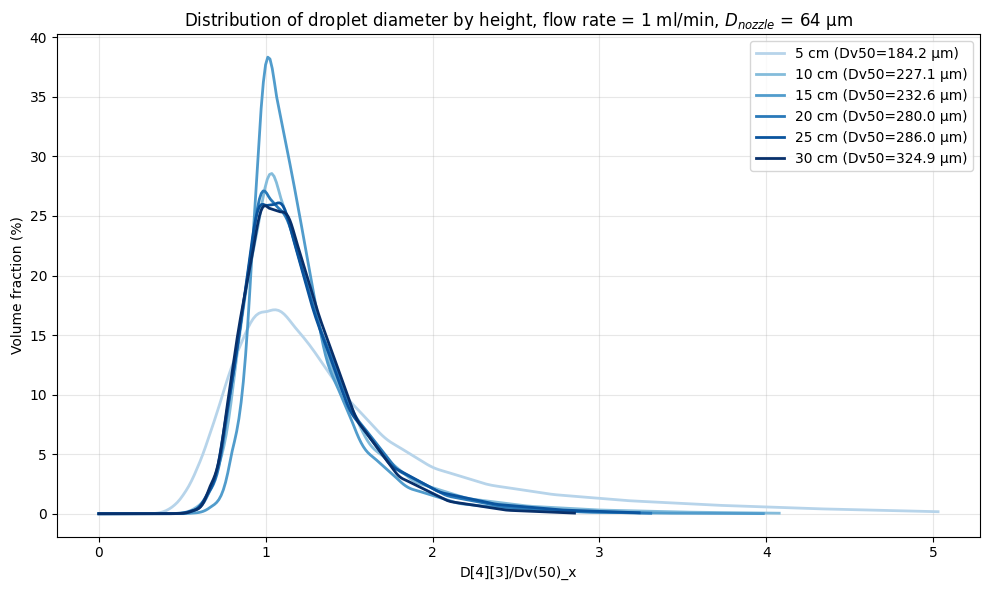

In [ ]:
BIN_PATTERN = re.compile(r'%\s*V\s*\(([\d.]+)-([\d.]+)\u00b5m\)')

def read_spraytec(filepath):
    with open(filepath, 'r', encoding='latin-1') as f:
        lines = f.readlines()

    header_idx = next(i for i, l in enumerate(lines) if BIN_PATTERN.search(l))
    header = lines[header_idx].rstrip('\n').split(',')

    bin_cols = []
    diameters = []
    for i, h in enumerate(header):
        m = BIN_PATTERN.match(h.strip())
        if m:
            low, high = float(m.group(1)), float(m.group(2))
            bin_cols.append(i)
            diameters.append((low * high) ** 0.5) 

    diameter = np.array(diameters)
    last_col = max(bin_cols)

    rows = []
    for line in lines[header_idx + 1:]:
        if not line.strip():
            continue
        fields = line.rstrip('\n').split(',')
        if len(fields) <= last_col:
            continue
        try:
            rows.append([float(fields[i]) for i in bin_cols])
        except ValueError:
            continue

    volume_matrix = np.array(rows)
    volume = volume_matrix.mean(axis=0)  
    return diameter, volume
def compute_dv(D, V, p):
    idx = np.argsort(D)
    D = D[idx]
    V = V[idx]

    cumV = np.cumsum(V)
    cumV = cumV / cumV[-1]

    return np.interp(p, cumV, D)

def clean_curve(D, V):
    idx = np.argsort(D)
    D = D[idx]
    V = V[idx]

    D_fine = np.linspace(D.min(), D.max(), 300)
    V_fine = np.interp(D_fine, D, V)

    V_log = np.log1p(V_fine)
    V_smooth = savgol_filter(V_log, 11, 2)

    return D_fine, np.expm1(V_smooth)

files = [
    '5cm_flowrate1_nozzle64_dis.txt',
    '10cm_flowrate1_nozzle64_dis.txt',
    '15cm_flowrate1_nozzle64_dis.txt',
    '20cm_flowrate1_nozzle64_dis.txt',
    '25cm_flowrate1_nozzle64_dis.txt',
    '30cm_flowrate1_nozzle64_dis.txt',
]

heights = np.array([5, 10, 15, 20, 25, 30])

D0, V0 = read_spraytec(files[list(heights).index(10)])
Dv50_10cm = compute_dv(D0, V0, 0.5)

plt.figure(figsize=(10, 6))
colors = plt.cm.Blues(np.linspace(0.3, 1.0, len(files)))

for (f, h), color in zip(zip(files, heights), colors):
    D, V_raw = read_spraytec(f)
    D_s, V_s = clean_curve(D, V_raw)

    Dv50 = compute_dv(D, V_raw, 0.5)  # each file's own Dv50

    plt.plot(D_s / Dv50, V_s, color=color, linewidth=2, label=f'{h} cm (Dv50={Dv50:.1f} μm)')

plt.xlabel("D[4][3]/Dv$(50)_x$")
plt.ylabel("Volume fraction (%)")
plt.title("Distribution of droplet diameter by height, flow rate = 1 ml/min, $D_{nozzle}$ = 64 μm")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
